<a href="https://colab.research.google.com/github/jpzorrilla/proyecto_analisis_datos/blob/main/proyecto_Del_dato_crudo_a_la_decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Del dato crudo a la decisión

## Objetivo general y objetivos específicos

Desarrollar un mini-proyecto o demo didáctica que permita:
- Cargar y explorar un dataset real o público.
- Evaluar y documentar la calidad del dato.
- Consultar los datos con SQL respondiendo a preguntas de negocio.
- Analizarlos y comunicar resultados mediante visualizaciones analíticas (Python o dashboard BI)
- Cerrar con storytelling: conclusiones y una recomendación accionable y mirada
ética.
- Diseñar una guía pedagógica que muestre cómo se podría usar esta actividad en
una clase real.

## I. Datos (calidad y limpieza)

Lo primero que vamos a hacer será obtener la información, guardarla en un DataFrame y visualizar las primeras filas de nuestro dataset.

In [1]:
# Importamos las librerias que necesitamos
import pandas as pd

# URL del dataset de la UNESCO
url = "https://data.unesco.org/api/explore/v2.1/catalog/datasets/wdi001/exports/csv/?delimiter=%2C&lang=es&timezone=Europe%2FParis&use_labels=true"

# Lectura directa desde el enlace
df_raw = pd.read_csv(url, sep=',')

# Visualizar las primeras cinco filas del DataFrame
df_raw.head()

,Año,Grupo regional,País,PIB Total,Tasa de crecimiento del PIB,PIB per cápita,Tasa de alfabetización juvenil,Tasa de alfabetización de adultos,Matriculación en primaria,Matriculación en secundaria,...,Esperanza de vida,Población de 0 a 14 años,Población de 15 a 64 años,Población mayor de 65 años,Población Total,Población femenina,Población masculina,Coordenadas,Código ISO2,Afiliación
0,1960,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,72.094,2570.0,6275.0,666.0,9510.0,49.337539,50.662461,"42.51, 1.52",AD,1. Member State
1,1963,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,73.298,3359.0,7873.0,683.0,11915.0,48.392782,51.607218,"42.51, 1.52",AD,1. Member State
2,1964,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,73.624,3642.0,8438.0,684.0,12764.0,48.135381,51.864619,"42.51, 1.52",AD,1. Member State
3,1967,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,74.119,4729.0,10339.0,770.0,15837.0,47.382711,52.617289,"42.51, 1.52",AD,1. Member State
4,1969,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,74.296,5640.0,12001.0,915.0,18555.0,46.871463,53.128537,"42.51, 1.52",AD,1. Member State


In [ ]:
"""
# SI NO FUNCIONARÁ LA WEB AL MOMENTO DE HACER LA CONSULTA EN LA CELDA ANTERIOR
# Puedes leer el archivo de manera local
# Carga el archivo 'wdi001.csv' en Colab
# Descomentar el código (eliminar solamente """ """) y ejecutar la celda.

# Importar libreria
import pandas as pd

# Leer el archivo
df_raw = pd.read_csv('/content/wdi001.csv')

# Visualizar las primeras cinco filas del DataFrame
df_raw.head()
"""

### Descripción de nuestro conjunto de datos

El conjunto de datos de *Indicadores de Desarrollo Mundial* es una recopilación exhaustiva de estadísticas relevantes, de alta calidad y comparables a nivel internacional sobre el desarrollo global. Presenta los datos más actualizados y precisos disponibles sobre el desarrollo global, e incluye estimaciones a nivel nacional, regional y global.

El conjunto de datos comprende 13.332 registros distribuidos en 25 columnas, agrupadas en las siguientes categorías principales:
1. Ubicación y Clasificación (Geografía y Tiempo)
    - **Año**: Año de observación del registro
    - **Grupo regional**: Grupo regional o continente al que pertenece el país (ej. Europe and North America, Arab States)
    - **País**: Nombre del país en inglés
    - **Código ISO2**: Código ISO alfa-2 del país (dos letras)
    - **Coordenadas**: Coordenadas geográficas (latitud y longitud)
    - **Afiliación**: Estado de membresía en la UNESCO
2. Indicadores Económicos
    - **PIB Total**: Producto Interior Bruto total expresado en dólares estadounidenses corrientes
    - **Tasa de crecimiento del PIB**: Tasa de crecimiento anual del PIB en porcentaje (%)
    - **PIB per cápita**: PIB per cápita en dólares corrientes
3. Educación y Alfabetización
    - **Tasa de alfabetización juvenil**: Tasa de alfabetización en la población joven
    - **Tasa de alfabetización de adultos**: Tasa de alfabetización en la población adulta
    - **Matriculación en primaria**: Tasa de matriculación en educación primaria
    - **Matriculación en secundaria**: Tasa de matriculación en educación secundaria
    - **Matriculación en escuelas terciarias**: Tasa de matriculación en educación superior o terciaria
4. Empleo y Mercado Laboral
    - **Población activa Mujer**: Tasa de participación femenina en la fuerza laboral
    - **Población activa Hombres**: Tasa de participación masculina en la fuerza laboral
    - **Población activa Total**: Fuerza laboral total o tasa global de participación laboral
    - **Tasa de desempleo**: Tasa de desempleo total (%)
5. Demografía y Salud
    - **Esperanza de vida**: Esperanza de vida al nacer (medida en años)
    - **Población de 0 a 14 años**: Población comprendida entre los 0 y 14 años
    - **Población de 15 a 64 años**: Población en edad de trabajar (15 a 64 años)
    - **Población mayor de 65 años**: Población de 65 años o más
    - **Población Total**: Población total del país
    - **Población femenina**: Porcentaje o volumen de población femenina
    - **Población masculina**: Porcentaje o volumen de población masculina

- **Fuente de los datos**: UNESCO / Banco Mundial - World Development Indicators.

- **Licencia**: Creative Commons Attribution-ShareAlike 4.0 International ([CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/deed.es)).

- **Fecha de actualización**: 20 de agosto de 2026.

## Preguntas de negocio

Principal:
- ¿Qué factores económicos, educativos y laborales están más asociados con las diferencias en desarrollo humano entre países y regiones durante el período 2015-2025?

Secundarias:
1. ¿Qué regiones presentan mejores resultados en esperanza de vida y cómo se relacionan con sus niveles de riqueza y empleo?
2. ¿Existe una relación significativa entre educación (alfabetización) y bienestar social (esperanza de vida)?
3. ¿Qué países muestran mayores desigualdades laborales por género y cuáles son sus condiciones de desempleo?

### Análisis Exploratorio de los Datos (EDA)

Primero verificamos la cantidad de filas duplicadas en nuestro conjunto de datos, sus dimensiones y el consumo de memoria.

In [2]:
# Dimensiones
print("Filas:", df_raw.shape[0])
print("Columnas:", df_raw.shape[1])

# Filas duplicadas
print("Filas duplicadas:", df_raw.duplicated().sum())

# Memoria utilizada
print(f"Memoria: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Filas: 13332
Columnas: 25
Filas duplicadas: 0
Memoria: 5.90 MB


#### Informe de Calidad de los Datos

A continuación, creamos un primer informe que nos ayudará a conocer la calidad inicial de nuestros datos.

In [3]:
def generar_informe_calidad(df_raw):
    """
    Genera un informe resumido de la calidad de datos de un DataFrame.
    Calcula métricas clave por columna: tipos de datos, nulos, porcentajes,
    valores únicos y conteo de ceros.
    """

    # Obtener el total de registros (filas) para usarlo de base en el cálculo de porcentajes
    total = len(df_raw)

    # Calcular valores nulos y únicos previamente para optimizar y reutilizar sus datos en los porcentajes
    nulos = df_raw.isna().sum()
    unicos = df_raw.nunique()

    # Construir el DataFrame con las métricas consolidadas por columna
    informe = pd.DataFrame({
        "Tipo": df_raw.dtypes,  # Tipo de dato (int, float, object, etc.)
        "No Nulos": df_raw.notna().sum(),  # Cantidad de datos presentes (no nulos)
        "Nulos": nulos,  # Cantidad de datos faltantes (NaN/None)
        "% Nulos": (
            nulos / total * 100
        ).round(
            2
        ),  # Porcentaje de datos nulos con respecto al total
        "Valores Únicos": unicos,  # Cantidad de valores distintos/únicos
        "% Únicos": (
            unicos / total * 100
        ).round(
            2
        ),  # Porcentaje de diversidad de datos
        "Ceros": df_raw.eq(
            0
        ).sum(),  # Cantidad de registros que equivalen exactamente a 0
    })

    # Devuelve la tabla formateada con el reporte
    return informe


# Invocar la función pasando el DataFrame 'df' a analizar
informe = generar_informe_calidad(df_raw)

# Nos muestra el informe
informe

,Tipo,No Nulos,Nulos,% Nulos,Valores Únicos,% Únicos,Ceros
Año,int64,13332,0,0.00,66,0.50,0
Grupo regional,object,13332,0,0.00,10,0.08,0
País,object,13332,0,0.00,202,1.52,0
PIB Total,float64,11276,2056,15.42,11274,84.56,0
Tasa de crecimiento del PIB,float64,10947,2385,17.89,10932,82.00,16
PIB per cápita,float64,11276,2056,15.42,11276,84.58,0
Tasa de alfabetización juvenil,float64,1253,12079,90.60,834,6.26,0
Tasa de alfabetización de adultos,float64,1108,12224,91.69,968,7.26,0
Matriculación en primaria,float64,7311,6021,45.16,7303,54.78,0
Matriculación en secundaria,float64,6133,7199,54.00,6129,45.97,2


**Pregunta**: *¿Qué información obtenemos a partir de estos datos?*

Escribir aquí las decisiones (obtenidas por los alumnos):

-
-
-


#### Análisis de los estadísticos descriptivos

`describe()` es una función de **Pandas** que se usa para obtener un **resumen estadístico rápido** de un `DataFrame`. Sirve principalmente para explorar y entender los datos antes de analizarlos o modelarlos.

Por defecto, analiza las **columnas numéricas** y devuelve, para cada una:

- **`count`**: número de valores no nulos.
- **`mean`**: media.
- **`std`**: desviación estándar.
- **`min`**: valor mínimo.
- **`25%`, `50%`, `75%`**: percentiles (el `50%` es la mediana).
- **`max`**: valor máximo.



In [4]:
# Obtener los estadísticos descriptivos
df_raw.describe()

,Año,PIB Total,Tasa de crecimiento del PIB,PIB per cápita,Tasa de alfabetización juvenil,Tasa de alfabetización de adultos,Matriculación en primaria,Matriculación en secundaria,Matriculación en escuelas terciarias,Población activa Mujer,Población activa Hombres,Población activa Total,Tasa de desempleo,Esperanza de vida,Población de 0 a 14 años,Población de 15 a 64 años,Población mayor de 65 años,Población Total,Población femenina,Población masculina
count,13332.000000,1.127600e+04,10947.000000,11276.000000,1253.000000,1108.000000,7311.000000,6133.000000,5282.000000,6502.000000,6502.000000,6502.000000,6321.000000,13096.000000,1.330200e+04,1.330200e+04,1.330200e+04,1.330200e+04,13332.000000,13332.000000
mean,1992.500000,2.532926e+11,3.664124,9153.673435,89.563375,81.123134,96.405666,65.899043,28.135136,49.957168,72.234662,61.210509,7.982826,64.915380,8.826305e+06,1.832587e+07,2.248842e+06,2.940101e+07,50.089400,49.910600
std,19.051086,1.383653e+12,6.730205,18684.339905,16.093043,20.354249,22.191129,35.397971,27.937799,16.277142,9.612687,11.121945,6.069761,11.343216,3.277919e+07,7.390733e+07,9.597902e+06,1.133643e+08,2.701156,2.701156
min,1960.000000,2.585956e+06,-64.047107,11.801322,14.380000,8.830000,3.118000,0.000000,0.000000,4.663000,23.605000,23.123000,0.100000,10.989000,1.106000e+03,1.383000e+03,6.400000e+01,2.715000e+03,23.817993,44.095020
25%,1976.000000,1.534831e+09,1.250754,594.787018,86.059998,70.815001,91.884106,34.770949,4.552934,41.581500,66.538250,54.816000,3.600000,58.003750,2.744398e+05,4.699268e+05,3.797700e+04,7.958510e+05,49.597467,48.769449
50%,1992.500000,9.009093e+09,3.786513,2059.996479,97.570000,90.369999,100.480820,71.774498,17.896343,51.580500,72.560500,61.310000,6.205000,67.549183,1.584809e+06,2.958080e+06,2.485165e+05,5.003536e+06,50.388702,49.611298
75%,2009.000000,5.916833e+10,6.253015,8340.471761,99.059998,95.819387,107.409515,95.052483,47.329685,59.955750,78.911500,67.406750,10.700000,73.215085,5.869362e+06,9.470252e+06,9.898145e+05,1.664787e+07,51.230551,50.402533
max,2025.000000,3.076970e+13,149.972963,288001.574856,100.000000,100.000000,214.642624,164.079819,166.389557,90.451000,95.893000,90.094000,38.800000,86.497000,3.897366e+08,1.001696e+09,2.097420e+08,1.463866e+09,55.904980,76.182007


**¿Para qué sirve en la práctica?**

- **Detectar valores atípicos (*outliers*):** Comparar la media con la mediana (`50%`), o el valor máximo (`max`) con el percentil `75%`, permite identificar de inmediato si existen números desproporcionadamente altos o bajos que distorsionan nuestros datos.
- **Entender la escala:** Permite ver rápidamente en qué rangos se mueven las variables (por ejemplo, edades entre 18 y 85 años frente a salarios entre 20.000 y 150.000).
- **Verificar valores nulos de un vistazo:** Si el valor del conteo (`count`) es menor al total de filas del conjunto de datos, significa que esa columna contiene datos faltantes.

**Discusión**: *¿Qué operaciones de limpieza de los datos podríamos realizar sobre nuestro DataFrame?*

**Escribir aquí las observaciones**:

- Eliminar las columnas que estamos 100% seguros que no son necesarias: Coordinadas y Afiliación.
- Eliminar los casos perdidos (valores nulos) en las variables con menor incidencia en el DataFrame (<237).
- En nuestro DataFrame no existen filas duplicadas y en una primera revisión no se detectaron valores extremos. Por lo cual, estas operaciones no son necesarias en este punto del análisis.


#### Eliminación de columnas

In [5]:
# Creamos una copia para preservar los datos crudos
df_clean1 = df_raw.copy()

# En el nuevo DataFrame eliminamos las columnas Coordenadas y Afiliación
df_clean1 = df_clean1.drop(columns=["Coordenadas", "Afiliación"])

# Validamos el resultado
df_clean1.head()

,Año,Grupo regional,País,PIB Total,Tasa de crecimiento del PIB,PIB per cápita,Tasa de alfabetización juvenil,Tasa de alfabetización de adultos,Matriculación en primaria,Matriculación en secundaria,...,Población activa Total,Tasa de desempleo,Esperanza de vida,Población de 0 a 14 años,Población de 15 a 64 años,Población mayor de 65 años,Población Total,Población femenina,Población masculina,Código ISO2
0,1960,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,72.094,2570.0,6275.0,666.0,9510.0,49.337539,50.662461,AD
1,1963,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,73.298,3359.0,7873.0,683.0,11915.0,48.392782,51.607218,AD
2,1964,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,73.624,3642.0,8438.0,684.0,12764.0,48.135381,51.864619,AD
3,1967,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,74.119,4729.0,10339.0,770.0,15837.0,47.382711,52.617289,AD
4,1969,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,74.296,5640.0,12001.0,915.0,18555.0,46.871463,53.128537,AD


#### Eliminación de valores nulos

In [6]:
"""
Lista con los nombres exactos de las columnas sobre las que
se va a comprobar si hay valores nulos.
"""
columnas = [
    "Esperanza de vida",
    "Población de 0 a 14 años",
    "Población de 15 a 64 años",
    "Población mayor de 65 años",
    "Población Total"
]

"""
Crea un nuevo DataFrame (df_clean2) a partir de df_clean1
eliminando todas las filas que tengan al menos un valor nulo
en alguna de las columnas indicadas en 'columnas'.
El DataFrame original df_clean1 NO se modifica.
"""
df_clean2 = df_clean1.dropna(subset=columnas)

# Guarda el número de filas que tenía el DataFrame antes de la limpieza.
filas_antes = len(df_clean1)

# Guarda el número de filas que quedan después de eliminar los nulos.
filas_despues = len(df_clean2)

"""
Muestra por pantalla cuántas filas se han eliminado
(diferencia entre el estado inicial y el final).
"""
print("Filas eliminadas:", filas_antes - filas_despues)

# Muestra por pantalla cuántas filas quedan en el DataFrame limpio.
print("Filas restantes:", filas_despues)

Filas eliminadas: 236
Filas restantes: 13096


## II. SQL

En el siguiente apartado vamos a convertir nuestro DataFrame ( `clean2` ) en una base de datos para leerla usando SQLite y realizar algunas consultas a nuestra base de datos.

In [7]:
# Importamos SQLite
import sqlite3

# Conectar (crea el archivo si no existe)
conn = sqlite3.connect('/content/mi_base.db')

# Guardar el DataFrame como tabla
df_clean2.to_sql('indicadores_desarrollo', conn, if_exists='replace', index=False)


13096

***Q1. ¿Qué países presentan las mayores brechas de participación laboral entre hombres y mujeres durante 2015–2025, y cuál es su nivel promedio de desempleo?***

In [8]:
Q_01 = pd.read_sql("""

SELECT
    País,
    ROUND(AVG("Tasa de desempleo"), 2) AS "Desempleo Promedio",
    ROUND(AVG("Población activa Mujer"), 2) AS "Población activa Mujeres",
    ROUND(AVG("Población activa Hombres"), 2) AS "Población activa Hombres",
    ROUND(AVG("Población activa Hombres" - "Población activa Mujer"), 2) AS "Brecha Participacion Genero"
FROM
    indicadores_desarrollo
WHERE
    Año BETWEEN 2015 AND 2025
GROUP BY
    País
ORDER BY
    "Brecha Participacion Genero" DESC
LIMIT 10;

""", conn)

Q_01

,País,Desempleo Promedio,Población activa Mujeres,Población activa Hombres,Brecha Participacion Genero
0,Iraq,14.01,11.81,71.86,60.05
1,Oman,2.76,30.07,87.61,57.54
2,Afghanistan,11.82,14.51,70.77,56.25
3,Pakistan,4.63,23.41,79.43,56.02
4,Yemen,17.71,4.93,59.99,55.06
5,Iran (Islamic Republic of),10.33,15.06,68.84,53.78
6,Saudi Arabia,5.62,27.58,80.70,53.12
7,State of Palestine,25.12,17.76,70.40,52.64
8,Algeria,12.12,14.43,66.93,52.50
9,Egypt,9.05,18.47,69.52,51.05


**Observaciones destacadas**:
- Los países con mayor brecha de participación laboral de género (2015–2025) son Iraq, Oman, Afghanistan, Pakistan y Yemen, todos con brechas superiores al 55%.
- Los 10 países del top pertenecen a Oriente Medio, Norte de África y Asia Meridional.
- Su desempleo promedio es del 11.56%, pero varía desde el 2.76% de Oman hasta el 25.12% de Palestina.
- No se observa una clara correlación entre el desempleo y la brecha de género para este grupo de países.

***Q2. ¿Qué países presentan las condiciones económicas más desfavorables en términos de PIB per cápita y desempleo durante los últimos 10 años?***

In [9]:
Q_02 = pd.read_sql("""

SELECT
    País,
    ROUND(AVG("PIB per cápita"), 2) AS "PIB Per Capita Promedio",
    ROUND(AVG("Tasa de desempleo"), 2) AS "Tasa de desempleo promedio"
FROM
    indicadores_desarrollo
WHERE
    Año BETWEEN 2015 AND 2025
GROUP BY
    País
HAVING
    AVG("PIB per cápita") < 10000
    AND AVG("Tasa de desempleo") > 7
ORDER BY
    AVG("Tasa de desempleo") DESC
LIMIT 10;


""", conn)

Q_02

,País,PIB Per Capita Promedio,Tasa de desempleo promedio
0,Eswatini,3740.67,29.82
1,South Africa,6307.48,29.50
2,Djibouti,2899.88,26.42
3,State of Palestine,3498.71,25.12
4,Botswana,7251.23,21.26
5,Congo,2401.78,20.66
6,Gabon,7494.07,20.43
7,Libya,7627.84,19.27
8,Saint Vincent and the Grenadines,8893.70,19.21
9,Somalia,533.37,18.92


El análisis identifica los 10 países que, durante los últimos 10 años, combinan un PIB per cápita promedio inferior a 10.000 y una tasa de desempleo promedio superior al 7%. El objetivo es detectar economías que presentan simultáneamente un bajo nivel de renta por habitante y una elevada dificultad de acceso al empleo.

En conjunto, los resultados sugieren que un bajo PIB per cápita y un elevado desempleo aparecen conjuntamente en determinados países, aunque este análisis descriptivo no permite establecer que exista una relación causal entre ambas variables.

### Insertar una nueva tabla en nuestra base de datos

En la fuente original de nuestro análisis las regiones no se encuentran bien etiquetadas (ver Anexos 1 y 2), para solucionar esto, tenemos dos opciones:
1. Aplicar las transformaciones necesariarias para reemplazar y corregir los países y las regiones a las que pertenecen, o
2. Conectar otra tabla y asociar los países de nuestra fuente con las regiones de la nueva tabla.

*Solución*: Por cuestiones de agilidad y productividad, resulta más conveniente la segunda opción en la práctica.

**Descripción**

Tabla titulada *ISO-3166 Country and Dependent Territories Lists with UN Regional Codes* que incluye los nombres de los países, regiones y sub regiones, así como los códigos ISO.

- **Fuente de los datos**: [GitHub](https://github.com/lukes/ISO-3166-Countries-with-Regional-Codes/blob/master/all/all.csv).

- **Licencia**: Creative Commons Attribution-ShareAlike 4.0 International ([CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/deed.es)).

- **Fecha de actualización**: 30 de junio de 2024.

Cargamos el archivo a nuestro Google Colab, lo leemos en un DataFrame y lo insertamos en nuestra base de datos.

In [10]:
# URL directa al CSV de GitHub
url = "https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv"

# Leer el CSV directamente desde GitHub
df = pd.read_csv(url, encoding="utf-8")

# Volcamos la tabla dentro de nuestra base de datos SQLite
con = sqlite3.connect("mi_base.db")
df.to_sql("regiones", con, if_exists="replace", index=False)

249

In [ ]:
"""
# SI NO FUNCIONARÁ LA WEB AL MOMENTO DE HACER LA CONSULTA EN LA CELDA ANTERIOR
# Puedes leer el archivo de manera local
# Carga el archivo 'regiones.csv' en Colab
# Descomentar el código (eliminar solamente """ """) y ejecutar la celda.

# Importar libreria
import pandas as pd

# Leer el archivo
df = pd.read_csv("/content/regiones.csv", encoding="utf-8")

# Volcamos la nueva tabla dentro de nuestra base de datos
con = sqlite3.connect("mi_base.db")
df.to_sql("regiones", con, if_exists="replace", index=False)
"""

***Q3. ¿Qué regiones presentan, en promedio, los mayores niveles de PIB per cápita y cómo se relacionan estos niveles con sus tasas de desempleo??***

In [11]:
Q_03 = pd.read_sql("""

SELECT
    r.region,
    ROUND(AVG("PIB per cápita"), 2) AS "PIB Per Capita Promedio",
    ROUND(AVG("Tasa de desempleo"), 2) AS "Tasa de desempleo promedio"
FROM indicadores_desarrollo AS i
LEFT JOIN regiones AS r
    ON i."Código ISO2" = r."alpha-2"
WHERE r.region IS NOT NULL AND Año BETWEEN 2015 AND 2025
GROUP BY r.region
ORDER BY "PIB Per Capita Promedio" DESC;

""", conn)

Q_03

,region,PIB Per Capita Promedio,Tasa de desempleo promedio
0,Europe,42600.07,7.46
1,Americas,16348.26,7.73
2,Asia,14588.86,6.31
3,Oceania,13506.86,4.91
4,Africa,2625.86,8.86


Los datos no muestran una relación simple en la que un mayor PIB per cápita implique necesariamente menor desempleo. Por ejemplo, Europa tiene el PIB per cápita más elevado, pero también una tasa de desempleo superior a Asia y Oceanía.

Por tanto, el análisis plantea una cuestión interesante para profundizar: El nivel de riqueza promedio de una región parece no ser suficiente, por sí solo, para explicar sus diferencias en materia de desempleo.

***Q4. ¿Existe una relación entre el nivel de PIB per cápita y la esperanza de vida en los países con menor nivel de ingresos durante el período 2015-2025?***

In [12]:
Q_04 = pd.read_sql("""

SELECT
    i."País",
    r."sub-region",
    ROUND(i."PIB per cápita", 2) AS "PIB Per Capita",
    ROUND(i."Esperanza de vida", 2) AS "Esperanza de vida"
FROM indicadores_desarrollo AS i
LEFT JOIN regiones AS r
    ON i."Código ISO2" = r."alpha-2"
WHERE r."sub-region" IS NOT NULL
    AND i."PIB per cápita" IS NOT NULL
    AND i."Esperanza de vida" IS NOT NULL
    AND Año BETWEEN 2015 AND 2025
GROUP BY i."País", r."sub-region"
ORDER BY i."PIB per cápita"
LIMIT 10;

""", conn)

Q_04

,País,sub-region,PIB Per Capita,Esperanza de vida
0,Burundi,Sub-Saharan Africa,252.70,62.57
1,Central African Republic,Sub-Saharan Africa,366.32,51.93
2,Democratic Republic of the Congo,Sub-Saharan Africa,431.05,59.49
3,Madagascar,Sub-Saharan Africa,453.97,63.43
4,Niger,Sub-Saharan Africa,485.66,58.85
5,Malawi,Sub-Saharan Africa,495.77,63.91
6,Somalia,Sub-Saharan Africa,509.50,54.77
7,Afghanistan,Southern Asia,565.57,62.27
8,Mozambique,Sub-Saharan Africa,610.56,58.71
9,Gambia,Sub-Saharan Africa,650.06,63.39


Los resultados muestran que los 10 países con menor PIB per cápita se concentran principalmente en África subsahariana, con la excepción de Afganistán, perteneciente a Asia meridional.

Por ejemplo, República Centroafricana registra el PIB per cápita más bajo del grupo (366,32 dólares) y también una de las esperanzas de vida más bajas (51,93 años). En cambio, Malawi, con un PIB per cápita de 495,77 dólares, presenta una esperanza de vida de 63,91 años, superior a la de países con un PIB per cápita similar.

Por tanto, los datos sugieren una posible relación positiva entre nivel económico y esperanza de vida, pero no de manera estrictamente proporcional. El PIB per cápita por sí solo no parece explicar completamente las diferencias observadas en esperanza de vida.

Además, destaca la concentración geográfica: 9 de los 10 países pertenecen a África subsahariana, lo que indica que las diferencias de desarrollo económico y bienestar también pueden presentar una importante dimensión regional.

## III. Análisis con Python

En este apartado, vamos a traernos nuestra nueva Tabla conjunta del ejercicio anterior, vamos a limpiarla con el objetivo de reducir sus dimensiones, y vamos a llevar a cabo un nuevo análisis exploratorio de los datos (EDA).

In [13]:
# Nos traemos una nueva tabla que une la original + regiones
Q_05 = """
SELECT *
FROM indicadores_desarrollo AS i
LEFT JOIN regiones AS r
    ON i."Código ISO2" = r."alpha-2"
"""

# La guardamos en un DataFrame
df = pd.read_sql_query(Q_05, con)

# Verificamos el resultado
print(df.shape)
df.head()

(13096, 34)


,Año,Grupo regional,País,PIB Total,Tasa de crecimiento del PIB,PIB per cápita,Tasa de alfabetización juvenil,Tasa de alfabetización de adultos,Matriculación en primaria,Matriculación en secundaria,...,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,1960,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,AD,AND,20.0,ISO 3166-2:AD,Europe,Southern Europe,None,150.0,39.0,NaN
1,1963,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,AD,AND,20.0,ISO 3166-2:AD,Europe,Southern Europe,None,150.0,39.0,NaN
2,1964,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,AD,AND,20.0,ISO 3166-2:AD,Europe,Southern Europe,None,150.0,39.0,NaN
3,1967,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,AD,AND,20.0,ISO 3166-2:AD,Europe,Southern Europe,None,150.0,39.0,NaN
4,1969,Europe and North America,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,AD,AND,20.0,ISO 3166-2:AD,Europe,Southern Europe,None,150.0,39.0,NaN


**Nota**: Al terminar de trabajar con la base de datos en SQLite es una buena práctica cerrar la base de datos con `con.close()`. Aquí no se hace, ya que existen otras consultas a la base de datos en el notebook que en el caso de querer consultarse, la base de datos siga disponible para su consulta.



Eliminamos las columnas que sean redundantes y aquellas que no vamos a utilizar

In [14]:
columnas_a_eliminar = [
    "Grupo regional",
    "alpha-3",
    "country-code",
    "iso_3166-2",
    "intermediate-region",
    "region-code",
    "sub-region-code",
    "intermediate-region-code",
    "Código ISO2",
    "name",
    "alpha-2",
]

df = df.drop(columns=columnas_a_eliminar)

Revisamos el resultado de nuestro nuevo DataFrame y lo comparamos con la última versión (antes de convertirlo en una base de datos en SQLite).

In [15]:
# Informe comparativo entre dos conjuntos de datos
for nombre, antes, actual in [
    ("Filas",            df_clean2.shape[0], df.shape[0]),
    ("Columnas",         df_clean2.shape[1], df.shape[1]),
    ("Filas duplicadas", df_clean2.duplicated().sum(), df.duplicated().sum()),
    ("Memoria (MB)",
     f"{df_clean2.memory_usage(deep=True).sum() / 1024**2:.2f}",
     f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"),
]:
    print(f"{nombre:18} Antes: {antes:>10}  Actual: {actual:>10}")

Filas              Antes:      13096  Actual:      13096
Columnas           Antes:         23  Actual:         23
Filas duplicadas   Antes:          0  Actual:          0
Memoria (MB)       Antes:       4.34  Actual:       4.26


Repetimos nuestro informe de calidad ahora para nuestro DataFrame `df`

In [16]:
def generar_informe_calidad(df):
    """
    Genera un informe resumido de la calidad de datos de un DataFrame.
    Calcula métricas clave por columna: tipos de datos, nulos, porcentajes,
    valores únicos y conteo de ceros.
    """

    # Obtener el total de registros (filas) para usarlo de base en el cálculo de porcentajes
    total = len(df)

    # Calcular valores nulos y únicos previamente para optimizar y reutilizar sus datos en los porcentajes
    nulos = df.isna().sum()
    unicos = df.nunique()

    # Construir el DataFrame con las métricas consolidadas por columna
    informe = pd.DataFrame({
        "Tipo": df.dtypes,  # Tipo de dato (int, float, object, etc.)
        "No Nulos": df.notna().sum(),  # Cantidad de datos presentes (no nulos)
        "Nulos": nulos,  # Cantidad de datos faltantes (NaN/None)
        "% Nulos": (
            nulos / total * 100
        ).round(
            2
        ),  # Porcentaje de datos nulos con respecto al total
        "Valores Únicos": unicos,  # Cantidad de valores distintos/únicos
        "% Únicos": (
            unicos / total * 100
        ).round(
            2
        ),  # Porcentaje de diversidad de datos
        "Ceros": df.eq(
            0
        ).sum(),  # Cantidad de registros que equivalen exactamente a 0
    })

    # Devuelve la tabla formateada con el reporte
    return informe


# Invocar la función pasando el DataFrame 'df' a analizar
segundo_informe = generar_informe_calidad(df)

# Nos muestra el informe
segundo_informe

,Tipo,No Nulos,Nulos,% Nulos,Valores Únicos,% Únicos,Ceros
Año,int64,13096,0,0.00,65,0.50,0
País,object,13096,0,0.00,202,1.54,0
PIB Total,float64,11090,2006,15.32,11089,84.67,0
Tasa de crecimiento del PIB,float64,10762,2334,17.82,10747,82.06,16
PIB per cápita,float64,11090,2006,15.32,11090,84.68,0
Tasa de alfabetización juvenil,float64,1253,11843,90.43,834,6.37,0
Tasa de alfabetización de adultos,float64,1108,11988,91.54,968,7.39,0
Matriculación en primaria,float64,7298,5798,44.27,7290,55.67,0
Matriculación en secundaria,float64,6124,6972,53.24,6120,46.73,2
Matriculación en escuelas terciarias,float64,5273,7823,59.74,5257,40.14,11


Observese que tanto region como sub-region aparecen 65 valores nulos, después de una examinación (ver Anexo 3) se aprecia que corresponde a la Unión Europea etiquetada como país, esto se ha decidido mantener ya que este dato puede ser útil si se desea comparar el bloque económico frente a otras economías.

### Análisis entre grupos

En el siguiente apartado se presenta un análisis entre grupos con su interpretación estadística.

In [17]:
# Importación de librerias
from scipy.stats import ttest_ind


# 1. Seleccionar las variables necesarias

datos = df[[
    "País",
    "PIB per cápita",
    "Esperanza de vida"
]].dropna().copy()


# 2. Dividir los países en dos grupos según la mediana

mediana_pib = datos["PIB per cápita"].median()

datos["Grupo PIB"] = datos["PIB per cápita"].apply(
    lambda x: "PIB per cápita bajo" if x <= mediana_pib
    else "PIB per cápita alto"
)


# 3. Separar los grupos

grupo_bajo = datos.loc[
    datos["Grupo PIB"] == "PIB per cápita bajo",
    "Esperanza de vida"
]

grupo_alto = datos.loc[
    datos["Grupo PIB"] == "PIB per cápita alto",
    "Esperanza de vida"
]


# 4. Estadísticos descriptivos

media_bajo = grupo_bajo.mean()
media_alto = grupo_alto.mean()

n_bajo = grupo_bajo.count()
n_alto = grupo_alto.count()

diferencia = media_alto - media_bajo


# 5. Prueba t de Welch
# No asumimos que las varianzas de los dos grupos sean iguales.

t_stat, p_value = ttest_ind(
    grupo_alto,
    grupo_bajo,
    equal_var=False
)


# 6. Mostrar resultados

print("========== COMPARACIÓN ENTRE GRUPOS ==========")

print(f"Mediana del PIB per cápita: {mediana_pib:,.2f}")

print("\nGrupo PIB per cápita bajo:")
print(f"  Tamaño de muestra (n): {n_bajo}")
print(f"  Esperanza de vida media: {media_bajo:.2f} años")

print("\nGrupo PIB per cápita alto:")
print(f"  Tamaño de muestra (n): {n_alto}")
print(f"  Esperanza de vida media: {media_alto:.2f} años")

print("\nDiferencia de medias:")
print(f"  {diferencia:.2f} años")

print("\nPrueba t de Welch:")
print(f"  Estadístico t: {t_stat:.3f}")
print(f"  p-valor: {p_value:.4f}")


# 7. Interpretación estadística

alpha = 0.05

print("\n========== INTERPRETACIÓN ==========")

if p_value < alpha:
    print(
        "La diferencia de esperanza de vida entre ambos grupos "
        "es estadísticamente significativa (p < 0.05)."
    )
else:
    print(
        "No se encuentra evidencia suficiente para afirmar que "
        "la diferencia de esperanza de vida entre ambos grupos "
        "sea estadísticamente significativa (p >= 0.05)."
    )

print(
    "\nIMPORTANTE: una diferencia estadísticamente significativa "
    "no demuestra que un mayor PIB per cápita cause una mayor "
    "esperanza de vida. El análisis muestra una asociación entre "
    "las variables y puede estar influido por otros factores."
)

========== COMPARACIÓN ENTRE GRUPOS ==========
Mediana del PIB per cápita: 2,002.28

Grupo PIB per cápita bajo:
  Tamaño de muestra (n): 5545
  Esperanza de vida media: 57.90 años

Grupo PIB per cápita alto:
  Tamaño de muestra (n): 5545
  Esperanza de vida media: 73.45 años

Diferencia de medias:
  15.55 años

Prueba t de Welch:
  Estadístico t: 104.933
  p-valor: 0.0000

========== INTERPRETACIÓN ==========
La diferencia de esperanza de vida entre ambos grupos es estadísticamente significativa (p < 0.05).

IMPORTANTE: una diferencia estadísticamente significativa no demuestra que un mayor PIB per cápita cause una mayor esperanza de vida. El análisis muestra una asociación entre las variables y puede estar influido por otros factores.


Los países del grupo de PIB per cápita alto presentan, en promedio, una esperanza de vida superior a los países del grupo de PIB per cápita bajo, y la diferencia es estadísticamente significativa (p < 0,05). Sin embargo, este resultado evidencia una asociación y no permite concluir que un mayor PIB per cápita sea la causa de una mayor esperanza de vida. Otros factores económicos, sociales, sanitarios y educativos podrían explicar total o parcialmente la diferencia.

## IV. Visualizaciones

En el siguiente apartado se presenta un análisis visual de los datos, el cual nos puede ayudar a dar contexto, forma, patrones y capacidad de detectar cosas que los análisis cuantitativos no siempre muestran de forma tan clara como las visualizaciones.

### Matriz de Correlación

La matriz de correlación permite identificar tanto patrones relevantes para el análisis exploratorio como variables redundantes que deberían revisarse antes de construir modelos predictivos o de regresión.

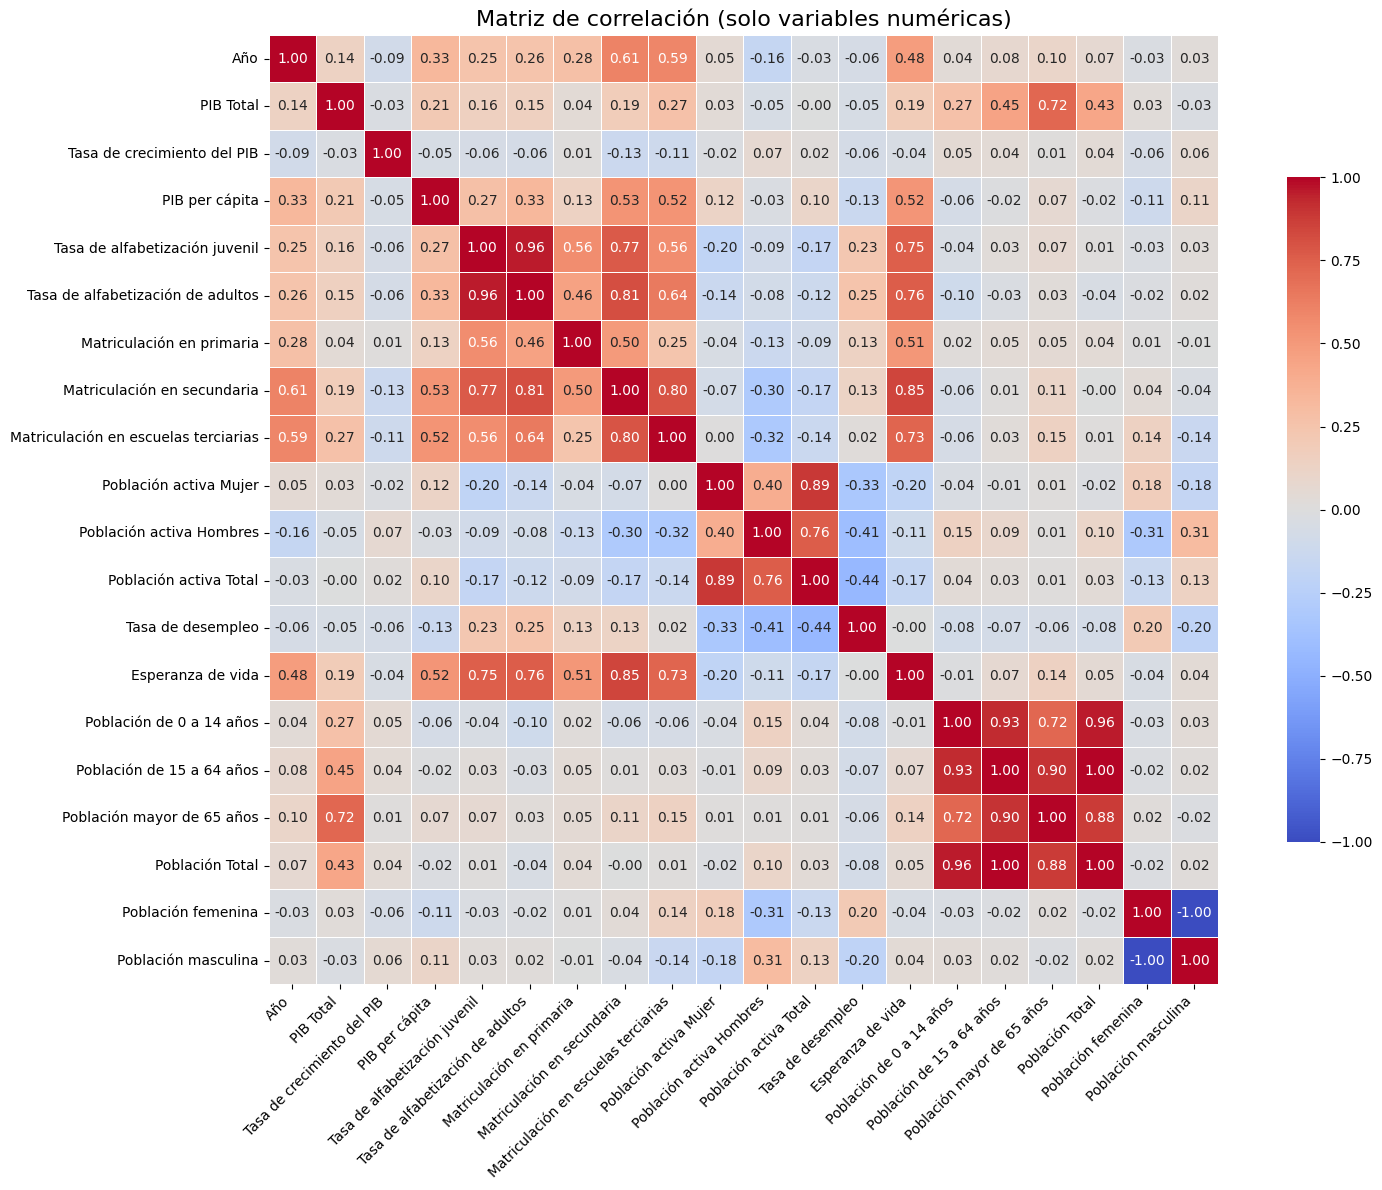

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
corr = df.corr(numeric_only=True)

# Visualizar
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)
plt.title("Matriz de correlación (solo variables numéricas)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Destacados clave**:
- En el análisis hay que eliminar al menos una de estas dos variables, ya que presentan problemas de multicolinealidad: Población masculina o femenina.
- Se pueden agrupan en el análisis las variables de relacionadas con la Salud y la Educación, ya que juntas presentan un fuerte valor explicativo a los problemas del desarrollo.
- El crecimiento del PIB no se relaciona con ninguna de las variables del conjunto de los datos.
- Mientras que, el PIB per cápita importa, pero solo explica la mitad de las diferencias en desarrollo humano.

### Gráfico de Violín

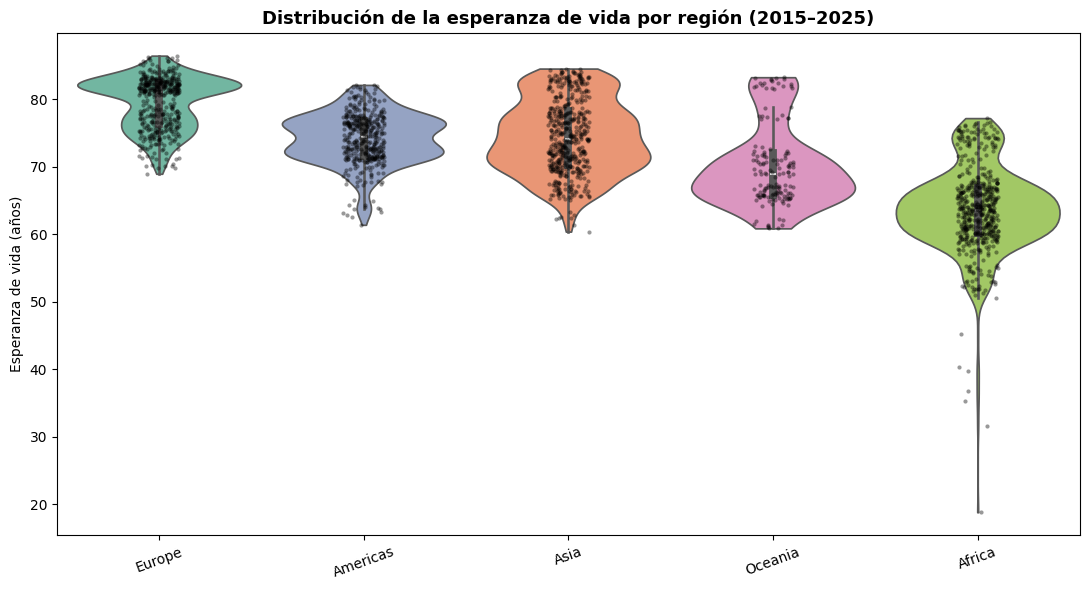

In [25]:
# Filtrar los últimos 10 años: 2015-2025
df_ultimos = df[
    df["Año"].between(2015, 2025)
].dropna(subset=["Esperanza de vida", "region"])

# Ordenar las regiones por mediana de esperanza de vida
orden = (
    df_ultimos.groupby("region")["Esperanza de vida"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Crear figura
fig, ax = plt.subplots(figsize=(11, 6))

# Gráfico de violín
sns.violinplot(
    data=df_ultimos,
    x="region",
    y="Esperanza de vida",
    hue="region",             # Corrección del FutureWarning
    order=orden,
    palette="Set2",
    inner="box",
    cut=0,
    legend=False,
    ax=ax
)

# Añadir observaciones individuales
sns.stripplot(
    data=df_ultimos,
    x="region",
    y="Esperanza de vida",
    order=orden,
    color="black",
    size=3,
    alpha=0.4,
    ax=ax
)

# Personalización
ax.set_title(
    "Distribución de la esperanza de vida por región (2015–2025)",
    fontsize=13,
    weight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Esperanza de vida (años)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

El gráfico de violín es especialmente adecuado aquí porque no sólo permite comparar el nivel central de la esperanza de vida entre regiones, sino también observar cómo se distribuyen los valores durante 2015–2025.

En particular, permite identificar:
- **Mediana**: la línea dentro del `box` muestra el valor central.
- **Dispersión**: el ancho del violín permite apreciar dónde se concentran los valores.
- **Forma de la distribución**: puedes detectar distribuciones asimétricas o posibles agrupamientos.
- **Valores individuales**: el `stripplot` superpuesto muestra las observaciones reales, evitando que el violín oculte el tamaño y la variabilidad de los datos.
- **Comparación entre regiones**: ordenar las regiones por mediana facilita comparar rápidamente sus niveles de esperanza de vida.

### Gráfico de dispersión

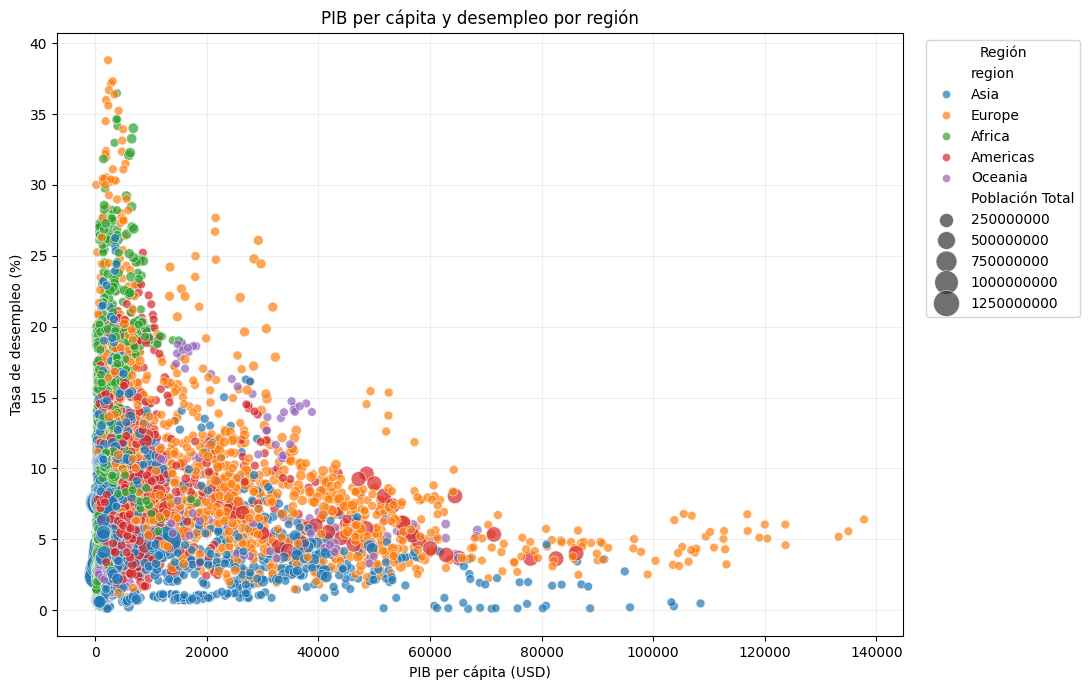

In [ ]:
df_plot = df.dropna(
    subset=[
        "PIB per cápita",
        "Tasa de desempleo",
        "region"
    ]
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_plot,
    x="PIB per cápita",
    y="Tasa de desempleo",
    hue="region",
    size="Población Total",
    sizes=(40, 400),
    alpha=0.7
)

plt.title("PIB per cápita y desempleo por región")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Tasa de desempleo (%)")
plt.legend(title="Región", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

El **gráfico de dispersión con tamaño de burbuja y color por región** es especialmente apropiado porque permite analizar tres dimensiones simultáneamente:
- **Eje X → PIB per cápita**: nivel de desarrollo económico.
- **Eje Y → tasa de desempleo**: situación del mercado laboral.
- **Color → región**: permite identificar diferencias geográficas.
- **Tamaño → población**: permite distinguir entre países/regiones pequeños y grandes.

Esto permite detectar patrones que serían difíciles de observar en una tabla. Por ejemplo, puedes identificar si existe una **relación negativa, positiva o débil entre PIB per cápita y desempleo**, además de observar si esa relación parece variar entre regiones.

También permite detectar **observaciones atípicas**: países con PIB per cápita relativamente alto pero desempleo elevado, o países con PIB per cápita bajo y desempleo reducido.

### Gráfico de dispersión con regresión lineal

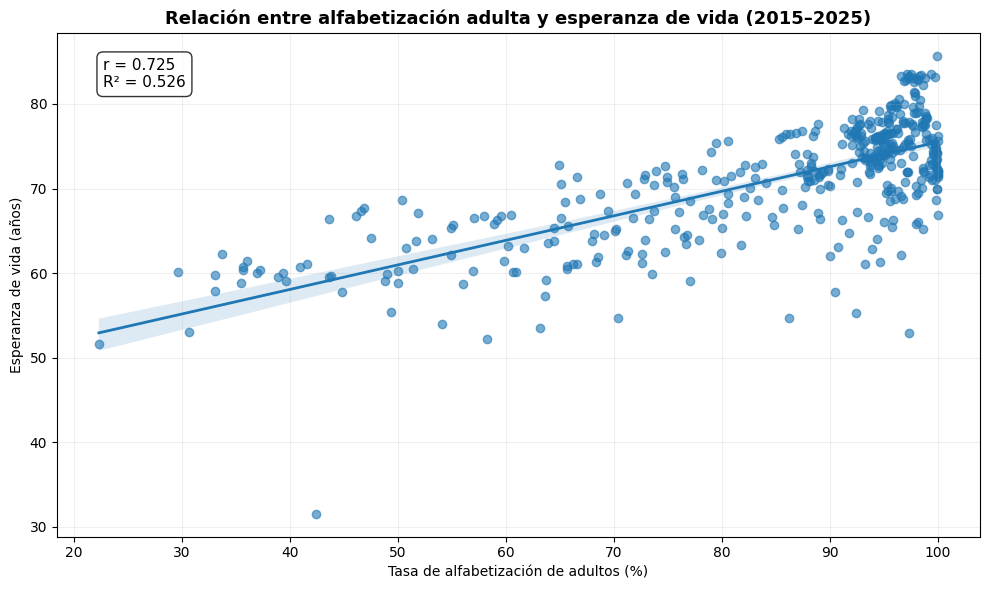

Coeficiente de correlación (r): 0.725
R²: 0.526
p-valor: 0.0000


In [29]:
# Importar R de Pearson
from scipy.stats import pearsonr

# Filtrar el período 2015-2025
df_ultimos = df[
    df["Año"].between(2015, 2025)
].dropna(
    subset=["Tasa de alfabetización de adultos", "Esperanza de vida"]
)

# Variables
x = df_ultimos["Tasa de alfabetización de adultos"]
y = df_ultimos["Esperanza de vida"]

# Calcular correlación de Pearson
r, p_valor = pearsonr(x, y)

# Calcular R²
r2 = r**2

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df_ultimos,
    x="Tasa de alfabetización de adultos",
    y="Esperanza de vida",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2},
    ax=ax
)

# Añadir r y R² al gráfico
ax.text(
    0.05, 0.95,
    f"r = {r:.3f}\nR² = {r2:.3f}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.8
    )
)

# Títulos y etiquetas
ax.set_title(
    "Relación entre alfabetización adulta y esperanza de vida (2015–2025)",
    fontsize=13,
    weight="bold"
)
ax.set_xlabel("Tasa de alfabetización de adultos (%)")
ax.set_ylabel("Esperanza de vida (años)")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Mostrar resultados estadísticos
print(f"Coeficiente de correlación (r): {r:.3f}")
print(f"R²: {r2:.3f}")
print(f"p-valor: {p_valor:.4f}")

Este gráfico es una buena visualización porque permite analizar la relación entre dos variables cuantitativas:
- Los puntos representan las observaciones de los países/regiones.
- La línea de regresión permite identificar la tendencia general entre alfabetización y esperanza de vida.
- La dispersión de los puntos permite observar si existe una relación fuerte o débil.
- También facilita detectar valores atípicos que se alejan considerablemente de la tendencia.
- Al limitar el análisis a 2015–2025, el gráfico se concentra en un período relativamente reciente.

En definitiva, el gráfico de dispersión es el más adecuado para estudiar la relación entre dos variables cuantitativas, y aquí se ve claramente una tendencia lineal positiva entre alfabetización y esperanza de vida. Además, incluye la línea de regresión con su banda de confianza y los valores de r y R², lo que resume la fuerza y dirección de la relación sin distorsionar la escala ni ocultar la dispersión real de los datos.

## V. Storytelling

### Principales conclusiones
- **La riqueza económica sola no garantiza el bienestar general ni el empleo**: Aunque existe una gran diferencia en la esperanza de vida entre países ricos y pobres (15.55 años de diferencia promedio, $p < 0.05$), el PIB per cápita solo explica cerca de la mitad del desarrollo humano. Además, regiones de altos ingresos como Europa presentan tasas de desempleo promedio más elevadas (7.46%) que regiones como Asia (6.31%) u Oceanía (4.91%).
- **Persiste una alarmante brecha laboral de género concentrada geográficamente**: Los 10 países con mayores desigualdades de inserción laboral femenina se ubican en Oriente Medio, Norte de África y Asia Meridional. En casos extremos como Irak, Omán, Afganistán, Pakistán y Yemen, la brecha de participación supera los 55 puntos porcentuales en favor de los hombres.
- **La educación es el verdadero motor del bienestar humano**: La tasa de alfabetización de adultos demuestra una correlación positiva sólida y directa con la esperanza de vida ($r = 0.725$, $R^2 = 0.526$). Más del 52% de la variación en los años de vida promedio de la población mundial se explica directamente por el acceso a la lectura y la educación.
- **Concentración geográfica del bajo desarrollo**: Los países con menor PIB per cápita (como Burundi, con 252.70 USD) y menor esperanza de vida se concentran abrumadoramente en el África subsahariana (9 de los 10 casos más severos del mundo).
- **Los datos disponibles son insuficientes para concluir causalidad**: Aunque la esperanza de vida del grupo de países con PIB alto es 15,55 años superior a la del grupo con PIB bajo (diferencia estadísticamente significativa, p < 0,05), esto no demuestra que el PIB cause directamente la mayor longevidad. Otros factores como el gasto sanitario, la educación o la estabilidad institucional podrían explicar total o parcialmente esa diferencia.

### Recomendación de política

- **Perfil Destinatario**: Dirección General de Organismos Internacionales y ONGs para el Desarrollo Humanitario (ej. UNESCO / PNUD).
- **Recomendación**: Priorizar programas integrados de empleo femenino, alfabetización adulta y acceso a servicios básicos en los países o territorios que combinan baja renta, desempleo elevado y baja esperanza de vida.

### Reflexión sobre sesgos, limitaciones y consideraciones éticas

**Limitaciones de la muestra**
- El conjunto contiene importantes cantidades de datos faltantes en variables educativas y laborales, superando en algunos casos el 50% y hasta el 90% de registros ausentes.
- Los países no disponen necesariamente del mismo número de observaciones para todas las variables.
- Algunos indicadores representan promedios nacionales y pueden ocultar desigualdades internas.

**Posibles sesgos**
- Sesgo geográfico derivado de la diferente calidad estadística entre países.
- Sesgo temporal al concentrar gran parte del análisis en el periodo 2015-2025.
- Sesgo de supervivencia debido a la exclusión de registros con valores faltantes.

**Consideraciones éticas**
- Correlación no implica causalidad. No debe afirmarse que la educación o el PIB causan directamente una mayor esperanza de vida sin análisis causal adicional.
- Los resultados deben utilizarse para diseñar políticas inclusivas y no para clasificar o estigmatizar países.
- Es importante contextualizar cualquier comparación internacional considerando diferencias históricas, culturales y políticas.

# ANEXOS

## Anexo 1

In [19]:
df_paises_agrupados = (
    df_raw.groupby('Grupo regional')['País']
    .agg(
        Países=lambda x: ', '.join(sorted(x.dropna().unique())),
        Numero_Paises='nunique'
    )
    .reset_index()
)

df_paises_agrupados

,Grupo regional,Países,Numero_Paises
0,Africa,"Angola, Benin, Botswana, Burkina Faso, Burundi...",47
1,Arab States,"Bahrain, Iraq, Jordan, Kuwait, Oman, Qatar, Sa...",11
2,"Arab States,Africa","Algeria, Egypt, Libya, Mauritania, Morocco, Tu...",6
3,"Arab States,Arab States",Lebanon,1
4,Asia and the Pacific,"Afghanistan, Australia, Bangladesh, Bhutan, Br...",44
5,"Asia and the Pacific,Europe and North America","Kazakhstan, Tajikistan",2
6,Europe and North America,"Albania, Andorra, Armenia, Austria, Azerbaijan...",50
7,"Europe and North America,Arab States",Malta,1
8,"Europe and North America,Asia and the Pacific","Russian Federation, Türkiye",2
9,Latin America and the Caribbean,"Antigua and Barbuda, Argentina, Aruba, Bahamas...",38


## Anexo 2

In [20]:
df_raw['Grupo regional'].apply(repr).value_counts()

,count
Grupo regional,
'Europe and North America',3300
'Africa',3102
'Asia and the Pacific',2904
'Latin America and the Caribbean',2508
'Arab States',726
"'Arab States,Africa'",396
"'Asia and the Pacific,Europe and North America'",132
"'Europe and North America,Asia and the Pacific'",132
"'Arab States,Arab States'",66


## Anexo 3

In [21]:
Q_06 = pd.read_sql("""

SELECT
    i."País"          AS pais,
    i."Código ISO2"   AS iso2,
    r."region",
    r."sub-region"
FROM indicadores_desarrollo AS i
LEFT JOIN regiones AS r
    ON i."Código ISO2" = r."alpha-2"
WHERE r."region" IS NULL
   OR r."sub-region" IS NULL
GROUP BY i."País"
ORDER BY i."País";

""", conn)

Q_06

,pais,iso2,region,sub-region
0,European Union,EU,None,None


## Anexo 4

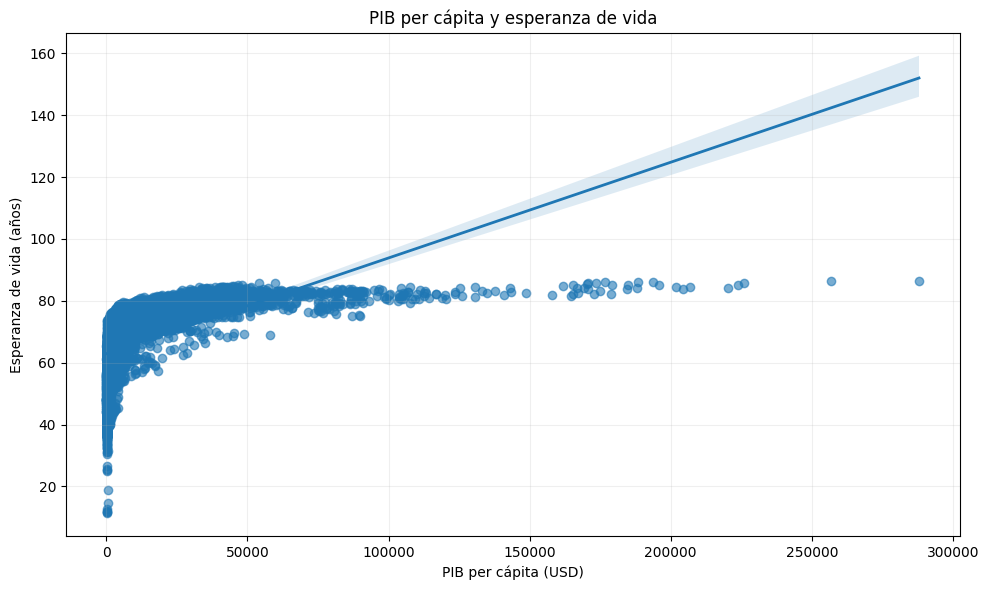

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="PIB per cápita",
    y="Esperanza de vida",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.title("PIB per cápita y esperanza de vida")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Esperanza de vida (años)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Visualizaciones descartadas ya que la proyección presenta una pendiente positiva la cual se aleja de la tendencia, por lo cual es una visulización que muestra una falsa tendencia positiva.

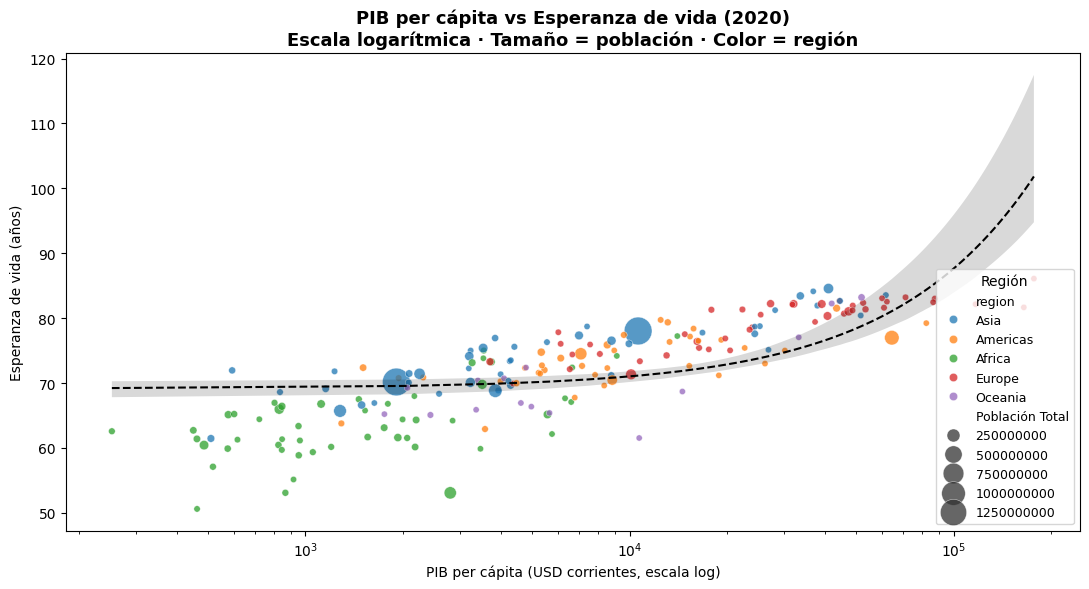

In [ ]:
# Usamos un solo año para evitar pseudoreplicación
anio_ref = 2020
sub = df[df["Año"] == anio_ref].dropna(
    subset=["PIB per cápita", "Esperanza de vida", "region"]
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=sub,
    x="PIB per cápita", y="Esperanza de vida",
    hue="region", size="Población Total",
    sizes=(20, 400), alpha=0.75, ax=ax
)
sns.regplot(
    data=sub, x="PIB per cápita", y="Esperanza de vida",
    scatter=False, color="black", line_kws={"linestyle": "--", "linewidth": 1.5},
    ax=ax
)
ax.set_xscale("log")  # el PIB per cápita es muy asimétrico → escala log
ax.set_title(f"PIB per cápita vs Esperanza de vida ({anio_ref})\n"
             f"Escala logarítmica · Tamaño = población · Color = región",
             fontsize=13, weight="bold")
ax.set_xlabel("PIB per cápita (USD corrientes, escala log)")
ax.set_ylabel("Esperanza de vida (años)")
ax.legend(title="Región", loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

Se descartó porque la curva se dispara y predice más de 100 años de esperanza de vida; el modelo no refleja el estancamiento real y la enorme banda de confianza delata un mal ajuste.

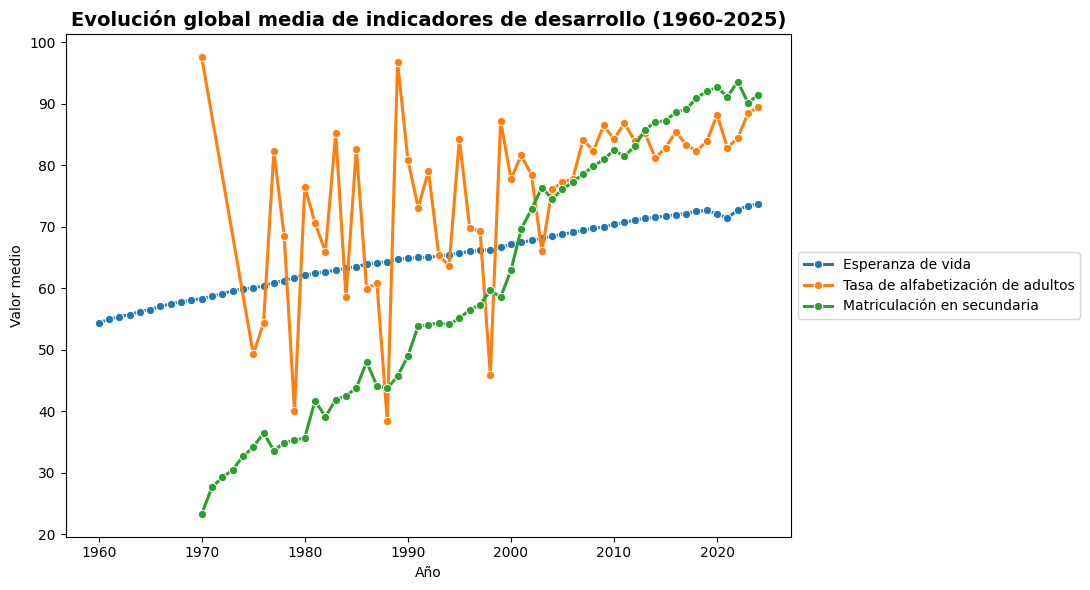

In [22]:
# Media global por año (para ver la tendencia agregada)
tendencia = (
    df.groupby("Año")[["Esperanza de vida",
                       "Tasa de alfabetización de adultos",
                       "Matriculación en secundaria"]]
      .mean()
      .reset_index()
      .melt(id_vars="Año", var_name="Indicador", value_name="Valor")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=tendencia,
    x="Año", y="Valor",
    hue="Indicador", marker="o", linewidth=2.2, ax=ax
)
ax.set_title("Evolución global media de indicadores de desarrollo (1960-2025)",
             fontsize=14, weight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Valor medio")
ax.legend(title="", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

La Tasa de alfabetización de adultos, es tan erratica que no permite ver una tendencia clara y real.